# Phase 1: Data Preprocessing
**MIS 637 B — Group 7**  
Diabetes 130-US Hospitals Dataset (1999–2008)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')


## 1. Load Data

In [2]:
# Download from: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
# Place diabetic_data.csv in ../data/
df = pd.read_csv('../data/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Missing Values

In [3]:
# '?' is used for missing in this dataset
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])

                   count    pct
weight             98569  96.86
max_glu_serum      96420  94.75
A1Cresult          84748  83.28
medical_specialty  49949  49.08
payer_code         40256  39.56
race                2273   2.23
diag_3              1423   1.40
diag_2               358   0.35
diag_1                21   0.02


In [4]:
# Drop cols with >40% missing (weight, payer_code, medical_specialty, max_glu_serum, A1Cresult)
drop_cols = missing_df[missing_df['pct'] > 40].index.tolist()
df.drop(columns=drop_cols, inplace=True)
print('Dropped:', drop_cols)

# Drop IDs — not predictive
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True, errors='ignore')

# Impute instead of dropping rows — preserves ~42K rows
# Numeric: fill with median; all others (object/string): fill with mode
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print('Shape after imputation:', df.shape)

Dropped: ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']
Shape after imputation: (101766, 44)


## 3. Target Binarization

target
0    90409
1    11357
Name: count, dtype: int64


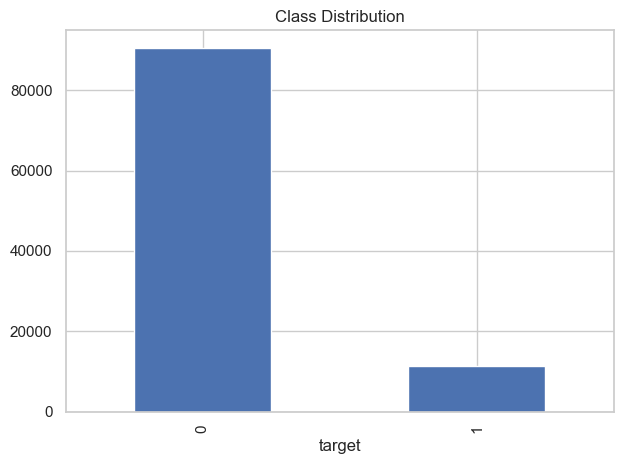

In [5]:
# Binary target: 1 = readmitted <30 days, 0 = everything else
df['target'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print(df['target'].value_counts())
df['target'].value_counts().plot(kind='bar', title='Class Distribution')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()

## 4. Encode Categoricals

In [6]:
# Identify ordinal vs nominal columns
# Ordinal: age (already binned as string like '[0-10)'), map to integer
age_map = {'[0-10)':0,'[10-20)':1,'[20-30)':2,'[30-40)':3,'[40-50)':4,
            '[50-60)':5,'[60-70)':6,'[70-80)':7,'[80-90)':8,'[90-100)':9}
if 'age' in df.columns:
    df['age'] = df['age'].map(age_map).fillna(4)  # unknown → mid-range

# Nominal: use one-hot encoding (drop_first to avoid multicollinearity)
nom_cols = df.select_dtypes(include='object').columns.tolist()
print('Nominal cols to one-hot encode:', nom_cols)
df = pd.get_dummies(df, columns=nom_cols, drop_first=True)
print('Shape after encoding:', df.shape)


Nominal cols to one-hot encode: ['race', 'gender', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


Shape after encoding:

 (101766, 2335)


/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_11242/2563037216.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nom_cols = df.select_dtypes(include='object').columns.tolist()


## 5. PCA

PCA: 2334 features → 2095 components


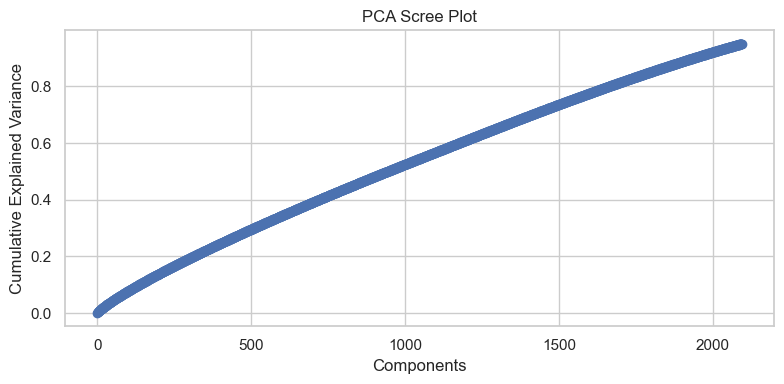

In [7]:
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)
print(f'PCA: {X.shape[1]} features → {X_pca.shape[1]} components')

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.tight_layout()
plt.savefig('../outputs/figures/pca_scree.png', dpi=150)
plt.show()

## 6. Save Preprocessed Data

In [8]:
import pickle

np.save('../data/X_scaled.npy', X_scaled)
np.save('../data/X_pca.npy', X_pca)
np.save('../data/y.npy', y.values)

with open('../outputs/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../outputs/models/pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print('Saved preprocessed data.')

Saved preprocessed data.
